# qBraid-SDK: Visualization

In this notebook, we'll go through some of the main features of the `qbraid.visualization` library.

## Circuit Drawer

First, we utilize the `circuit_drawer` function. This function takes in any type of support quantum circuit, and draws it out in the console.

In [1]:
from qbraid.interface import random_circuit
from qbraid.visualization import circuit_drawer

braket_circuit = random_circuit("braket")
circuit_drawer(braket_circuit)

T  : |   0    |   1    |   2    |   3    |   4    |5|  6  |   7    |   8    |   9    |   10   |11| 12  |   13   |   14   |   15   |   16   |17|18|
                                                                                                                                                  
q0 : ----------------------------------------------C-------------------------------------------C--Si----------------------------------------X--S--
                                                   |                                           |                                            |     
q1 : -Rz(1.57)-Rx(1.57)-Rz(3.14)-Rx(1.57)-Rz(3.14)-X-Rz(0)-Rx(1.57)-Rz(2.47)-Rx(1.57)-Rz(3.14)-X--Rz(0)-Rx(1.57)-Rz(3.81)-Rx(1.57)-Rz(1.57)-C-----

T  : |   0    |   1    |   2    |   3    |   4    |5|  6  |   7    |   8    |   9    |   10   |11| 12  |   13   |   14   |   15   |   16   |17|18|


Let's take this circuit and transpile it to another language to see that it can still be visualized.

In [2]:
from qbraid.transpiler import transpile

cirq_circuit = transpile(braket_circuit, "cirq")
circuit_drawer(cirq_circuit)

Additionally, if the library you are working with has options for visualization, those options can be expressed as `kwargs` in `circuit_drawer`. For example:

In [3]:
circuit_drawer(cirq_circuit)

## Conversion Graphs

Given a `ConversionGraph`, you can use `plot_conversion_graph` to display the connections between different quantum frameworks.

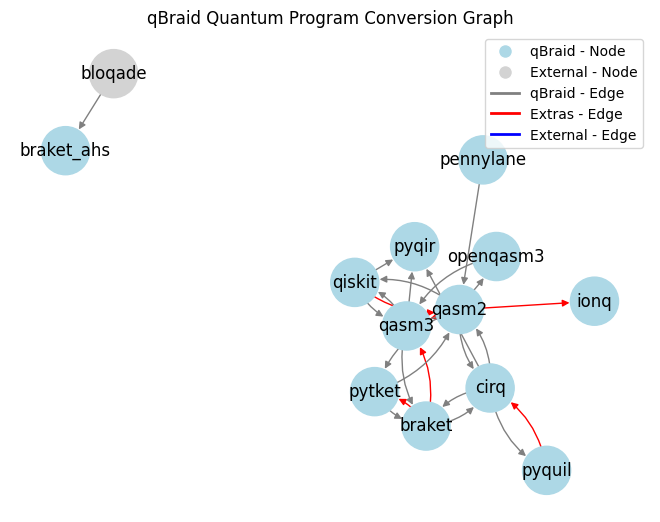

In [4]:
from qbraid.transpiler import ConversionGraph
from qbraid.visualization import plot_conversion_graph

graph = ConversionGraph()
plot_conversion_graph(graph, legend=True)

## Histograms/Distributions

When you have a qBraid quantum job, you can get the measurement counts from it and also plot it using the qBraid-SDK.

In [5]:
from qbraid.runtime import QbraidProvider

provider = QbraidProvider()
device = provider.get_device("aws:aws:sim:sv1")

In [7]:
from braket.circuits import Circuit

circuit = Circuit().h(0).cnot(0, 1)
result = device.run(circuit, shots=1000).result()

In [8]:
from qbraid.visualization import plot_histogram, plot_distribution

plot_histogram(result.data.measurement_counts)

In [11]:
plot_distribution(result.data.measurement_counts)